# NYC Bar Crawl Decision System

**A symbolic, explainable decision system for group bar-crawl planning.**

This notebook is the canonical demo. It walks end-to-end through the pipeline:
*intake → score → aggregate → route → explain → counterfactual*. 
Every decision the system makes is traceable to a rule or score comparison — not
a black-box recommender.

Five course-aligned techniques combine here:

1. **Multi-Criteria Decision Analysis** with Pareto filtering
2. **Qualitative reasoning** — cheap/moderate/premium, library/loud
3. **VOTE-style group aggregation** with meta-strategy selection
4. **Case-Based Reasoning** over 20 crawl archetypes
5. **Option generation & counterfactuals**

Dataset: 143 NYC bars enriched from the author's personal Google Maps list.
Names + ratings are real; hours and specials are category-based inferences (see writeup).

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd())) if 'notebooks' in os.getcwd() else sys.path.insert(0, os.getcwd())
from datetime import datetime
from IPython.display import display, Markdown, HTML

from src.data_loader import load_all
from src.decision_system import plan_crawl
from src.models import GroupInput, UserPreference, AccessibilityNeeds
from src.visualize import render_map, render_timeline, render_score_breakdown
from src.group_aggregation import disagreement_profile, select_strategy, aggregate
from src.scoring import score_bar_for_user, pareto_filter
from src.qualitative import qualify, phrase_for
from src.case_based import retrieve
from src.option_generation import strategy_counterfactuals, strategy_winner
from src.explanation_engine import render_served_table

loaded = load_all()
BARS, CASES, RULES = loaded['bars'], loaded['cases'], loaded['rules']
print(f'Loaded {len(BARS)} bars, {len(CASES)} cases, {len(RULES)} rule sections.')

Loaded 143 bars, 20 cases, 10 rule sections.


## 1. The group — three people, competing preferences

We'll use the same group throughout: **Alice, Bob, Carol** planning a Friday-night crawl
in the East Village / Lower East Side. Their tastes pull in different directions — which
is exactly the point. If a group were aligned, any scoring function would do. The real
test of a decision system is how it mediates disagreement.

In [2]:
alice = UserPreference(
    name='Alice',
    vibe_weights={'intimate': 1.0, 'conversation': 0.9, 'polished': 0.7},
    max_per_drink=20.0,
    preferred_drinks=('cocktails', 'wine'),
    preferred_noise='conversation',
)
bob = UserPreference(
    name='Bob',
    vibe_weights={'lively': 0.9, 'unpretentious': 0.8, 'local-institution': 0.7},
    max_per_drink=12.0,
    preferred_drinks=('beer',),
    preferred_noise='lively',
)
carol = UserPreference(
    name='Carol',
    vibe_weights={'hidden-gem': 0.9, 'conversation': 0.8, 'intimate': 0.6},
    max_per_drink=16.0,
    preferred_drinks=('cocktails',),
    preferred_noise='conversation',
)

group = GroupInput(
    users=[alice, bob, carol],
    start_time=datetime(2026, 4, 24, 19, 0),   # Fri 7pm
    end_time=datetime(2026, 4, 24, 23, 30),
    start_location=(40.7265, -73.9815),          # East Village
    max_stops=3,
    neighborhoods=('East Village', 'Lower East Side'),
)

print('Group:', ', '.join(u.name for u in group.users))
print('Window:', group.start_time.strftime('%a %H:%M'), '→', group.end_time.strftime('%H:%M'))
print(f'Budget caps: Alice ${alice.max_per_drink:.0f}, Bob ${bob.max_per_drink:.0f}, Carol ${carol.max_per_drink:.0f}')

Group: Alice, Bob, Carol
Window: Fri 19:00 → 23:30
Budget caps: Alice $20, Bob $12, Carol $16


## 2. Under the hood

Before we run the full planner, let's watch each layer do its part.

### 2.1 Per-user utility vectors

For any bar, each user gets a per-criterion score and a weighted contribution.
Here's Alice's view of three random bars:

In [3]:
import pandas as pd

sample = [b for b in BARS if b.name in ('Burp Castle', 'Please Don\'t Tell', 'McSorley\'s Old Ale House')]
rows = []
for b in sample:
    s = score_bar_for_user(b, alice, RULES, arrival_hour=21, day='fri', prev_location=group.start_location)
    rows.append({'bar': b.name, **s.per_criterion, 'TOTAL': s.total})
pd.DataFrame(rows).round(3)

,bar,vibe,budget,drink_match,noise,distance,happy_hour_active,specials_match,crowd_fit,novelty,quality_signal,TOTAL
0,Please Don't Tell,0.857,0.535,0.667,1.00,0.978,0.0,0.0,0.75,0.4,0.672,0.654
1,Burp Castle,0.265,1.000,0.500,0.75,0.978,0.0,0.0,0.75,0.4,0.563,0.530


The low numbers on `happy_hour_active` and `specials_match` reflect that 9pm is outside
typical happy-hour windows. The `budget` score is near-1 for bars under Alice's cap.

### 2.2 Pareto filtering

Before sinking compute into routing, we drop bars strictly dominated on every criterion
by another bar. The dropped bars aren't lost — their dominators get recorded, so the
explanation can tell the user *why* we didn't even consider them.

In [4]:
from src.scoring import score_bar_for_user, pareto_filter

# Score all bars for Alice; then run Pareto
all_scores = [score_bar_for_user(b, alice, RULES, arrival_hour=21, day='fri',
                                   prev_location=group.start_location) for b in BARS]
kept, dominated = pareto_filter(all_scores)
print(f'Out of {len(all_scores)} bars, {len(kept)} survive Pareto, {len(dominated)} dropped.')
print()
print('Sample drops:')
for loser, winner in dominated[:3]:
    lbar = next(b for b in BARS if b.id == loser.bar_id).name
    wbar = next(b for b in BARS if b.id == winner.bar_id).name
    print(f'  • {lbar:35s} dominated by {wbar}')

Out of 143 bars, 34 survive Pareto, 109 dropped.

Sample drops:
  • Sunswick 35/35                      dominated by The Bonnie
  • The Bonnie                          dominated by VALERIE
  • Bohemian Hall & Beer Garden         dominated by The Bonnie


### 2.3 Qualitative layer

Numbers in, labels out. Every attribute used in an explanation is tagged qualitatively
— this is what makes the text read like a person talking.

In [5]:
bar = next(b for b in BARS if 'Burp Castle' in b.name)
print(f'{bar.name} @ 9pm:')
prof = qualify(bar, 21, RULES)
for k, v in prof.items():
    phrase = phrase_for(v, k.replace('_tier', '').replace('_level', ''))
    print(f'  {k:15s} {v:20s}  →  "{phrase}"')
print(f'  user_note       {bar.user_note!r}')

Burp Castle @ 9pm:
  price_tier      moderate              →  "mid-priced"
  noise_level     library               →  "library-quiet"
  crowd           packed                →  "packed"
  quality         moderate_signal       →  "solid consensus"
  user_note       'Only whispering allowed lol'


## 3. Group aggregation — which strategy and why?

Before aggregating the three users' utilities, we compute a **disagreement profile**
and let a rule-based meta-selector pick the strategy. This is the VOTE-inspired part of
the project — and the piece the writeup is proudest of.

In [6]:
profile = disagreement_profile(group.users, BARS)
for k, v in profile.items():
    print(f'  {k:30s} {v:.3f}' if isinstance(v, float) else f'  {k:30s} {v}')

  dealbreaker_density            0.000
  budget_spread_ratio            1.667
  vibe_variance                  0.386
  max_preference_intensity       0.133
  group_size                     3


In [7]:
strat, rule, rationale = select_strategy(profile, RULES)
print(f'Chosen strategy : {strat}')
print(f'Rule that fired: {rule}')
print()
print('Rationale:')
print(' ', rationale)

Chosen strategy : copeland_pairwise
Rule that fired: strategy_copeland

Rationale:
  Vibe preferences diverge significantly across the group (variance = 0.39). Copeland pairwise-majority finds a Condorcet-style consensus robust to this split.


## 4. Running the full planner

In [8]:
result = plan_crawl(group, bars=BARS, cases=CASES, rules=RULES)

print('ROUTE:')
for i, s in enumerate(result.route.stops, 1):
    print(f'  {i}. {s.bar.name:35s} at {s.arrival.strftime("%H:%M")} ({s.bar.neighborhood})')
print()
print(f'Total walking:  {result.route.total_walking_miles:.2f} miles')
print(f'Strategy used:  {result.route.strategy_used}')
print(f'Excluded bars:  {len(result.excluded_bars)}')

ROUTE:
  1. Lost in Paradise Rooftop            at 19:13 (Lower East Side)
  2. Vida Verde - Tequila Bar            at 20:17 (East Village)
  3. Pineapple Club                      at 21:17 (Lower East Side)

Total walking:  1.66 miles
Strategy used:  copeland_pairwise
Excluded bars:  111


### The map

In [9]:
render_map(result.route, BARS)

### The timeline

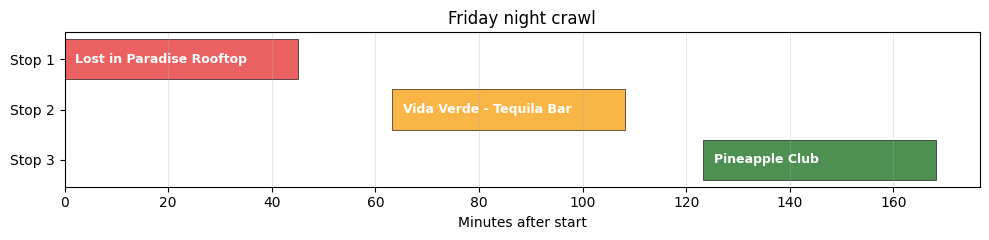

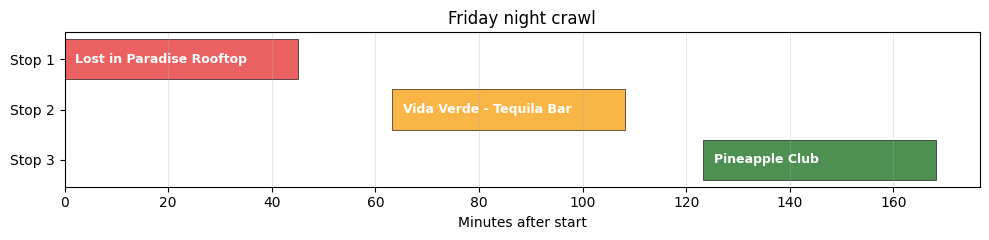

In [10]:
render_timeline(result.route, title='Friday night crawl')

### Per-stop score breakdown

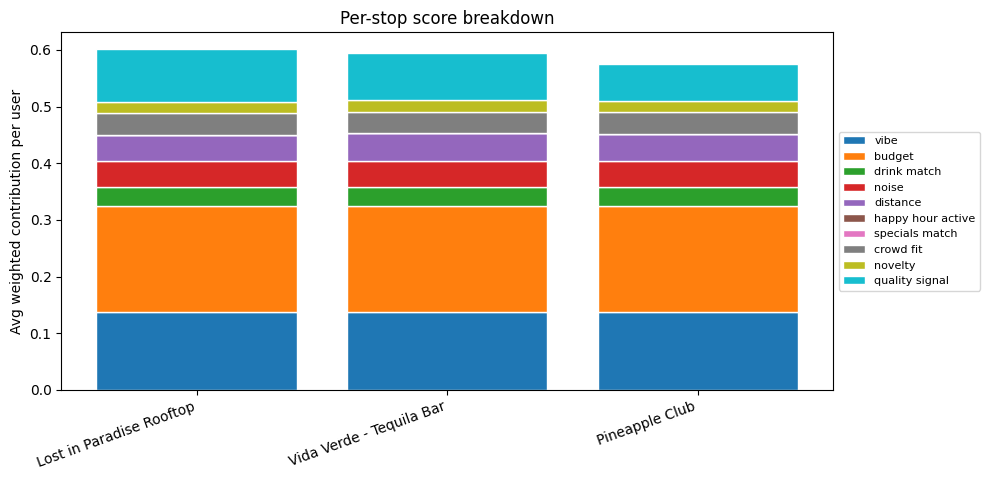

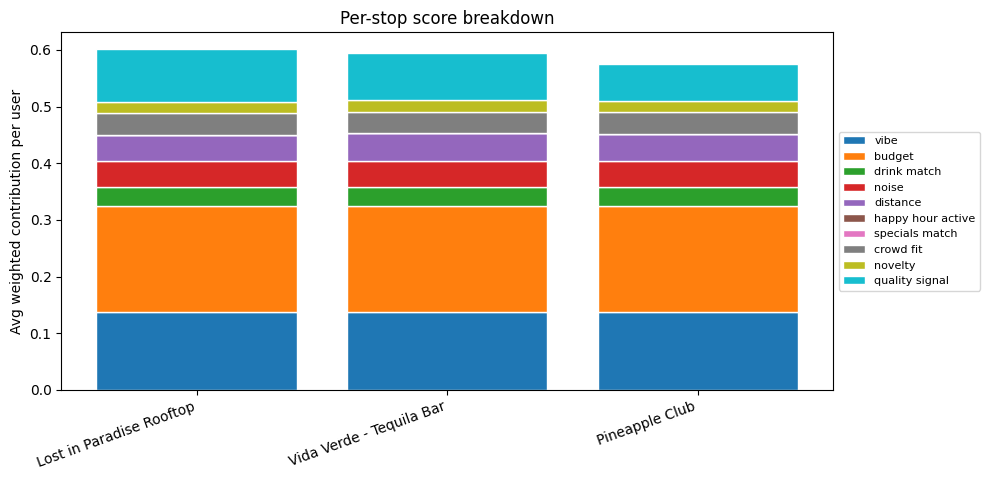

In [11]:
render_score_breakdown(result.route, result.traces['per_user_scores'])

## 5. Explanations

The top-level narrative:

In [12]:
display(Markdown(result.explanations.summary))

For Alice, Bob, Carol, here is a 3-stop crawl: Lost in Paradise Rooftop → Vida Verde - Tequila Bar → Pineapple Club. The plan captures 0 happy-hour/special windows and involves 1.7 miles of walking. The crawl threads through East Village, Lower East Side. Aggregated under the **copeland pairwise** strategy: Vibe preferences diverge significantly across the group (variance = 0.39). Copeland pairwise-majority finds a Condorcet-style consensus robust to this split.

The strategy rationale:

In [13]:
display(Markdown(result.explanations.children[0].summary))

We used Copeland pairwise-majority because vibe preferences diverge across the 3 of you (variance 0.39). Copeland runs every pair of bars through a majority vote and picks whichever wins the most pairwise contests — it's Condorcet-robust when tastes split.

Per-stop explanations:

In [14]:
for i, child in enumerate(result.explanations.children[1:1 + len(result.route.stops)], 1):
    display(Markdown(f'**Stop {i}.** {child.summary}'))

**Stop 1.** We open at **Lost in Paradise Rooftop** (7:13pm) — it fits the budget, and it's a mid-priced, conversational room in Lower East Side. Strong consensus pick: 4.7★ over 6,621 reviews. Alice scored this highest of the three.

**Stop 2.** From there, over to **Vida Verde - Tequila Bar** at 8:17pm, a mid-priced conversational spot in East Village. It fits the budget. Strong consensus pick: 4.6★ over 4,210 reviews.

**Stop 3.** Closing at **Pineapple Club** at 9:17pm, a mid-priced conversational spot in Lower East Side. It fits the budget. Matches the vibe you're after. Close second: The Back Room — it would have edged ahead if you'd had a tighter budget. Alice scored this highest of the three.

## 6. Option generation — *why not X instead?*

The system precomputes runner-ups, unlock hints, and counterfactuals. The user never
has to ask — the answers are already in the trace.

**Structural counterfactuals**  (what changes if the inputs shift?)

In [15]:
# The orchestrator ran these for us
cf_children = [c for c in result.explanations.children if c.summary == 'Counterfactuals']
if cf_children:
    for sub in cf_children[0].children:
        display(Markdown(f'• {sub.summary}'))
else:
    display(Markdown('(no counterfactuals produced)'))

• If the group had 30 more minutes, the crawl would have been identical — the same stops, same order.

• If each user had $10 more per drink, the crawl would have been identical — same stops but total utility would shift by +18.00.

**Strategy counterfactuals**  (who would win under each aggregation method?)

In [16]:
winners = result.traces.get('strategy_cf_winners', {})
if winners:
    rows = []
    for strat, bar_id in winners.items():
        if bar_id:
            bar = next((b for b in BARS if b.id == bar_id), None)
            rows.append({'strategy': strat, 'winner': bar.name if bar else '(no bar)', 
                          'chose this one?': '✓' if strat == result.route.strategy_used else ''})
    pd.DataFrame(rows)
else:
    pd.DataFrame()

## 7. Stakeholder taxonomy — per-user served-ness

Each user's view of how well the plan served *them* specifically.

In [17]:
display(Markdown(render_served_table(result.per_user_report)))

| User | mean score on route | top5 in route | vetoes respected | in budget stops |
|---|---|---|---|---|
| Alice | 0.76 | 3/5 | True | 3/3 |
| Bob | 0.386 | 0/5 | True | 0/3 |
| Carol | 0.625 | 3/5 | True | 3/3 |

## 8. Case-Based Reasoning — what archetype does this resemble?

In [18]:
top_cases = retrieve(group, CASES, top_k=3)
rows = []
for case, sim, breakdown in top_cases:
    rows.append({'case': case.name, 'similarity': round(sim, 3),
                 'narrative': case.success_narrative[:70] + '...'})
pd.DataFrame(rows)

,case,similarity,narrative
0,LES Speakeasy Ladder,0.738,"Opens with conversation, peaks in theatricalit..."
1,After-Dinner Nightcap,0.575,Just one well-chosen drink before heading home...
2,West Village Dignified Evening,0.513,Grown-up pacing; every stop supports real conv...


## 9. Edge cases — adversarial inputs

A decision system should fail gracefully. Three stress tests:

### 9.1 A user vetoes every cocktail bar

In [19]:
cocktail_ids = tuple(b.id for b in BARS if 'cocktail_bar' in b.bar_type)
alice_picky = UserPreference(**{**alice.__dict__, 'vetoes': cocktail_ids})
group_picky = GroupInput(users=[alice_picky, bob, carol],
                           start_time=group.start_time, end_time=group.end_time,
                           start_location=group.start_location, max_stops=3,
                           neighborhoods=group.neighborhoods)
r = plan_crawl(group_picky, bars=BARS, cases=CASES, rules=RULES, compute_counterfactuals=False)
print(f'Strategy: {r.route.strategy_used}')
print('Route:', ' → '.join(s.bar.name for s in r.route.stops) if r.route.stops else '(none)')
print(f'Excluded: {len(r.excluded_bars)}')
# None of the cocktail bars made it
route_types = {t for s in r.route.stops for t in s.bar.bar_type}
print(f'Route bar_types: {route_types}')

Strategy: copeland_pairwise
Route: McSorley’s Old Ale House → Barcade → Otto's Shrunken Head
Excluded: 121
Route bar_types: {'pub', 'generic_bar'}


### 9.2 Impossible time window (30 minutes, 5 stops)

In [20]:
group_tight = GroupInput(users=[alice, bob], start_time=datetime(2026, 4, 24, 19, 0),
                           end_time=datetime(2026, 4, 24, 19, 30), max_stops=5)
r = plan_crawl(group_tight, bars=BARS, cases=CASES, rules=RULES, compute_counterfactuals=False)
print('Route length:', len(r.route.stops))
display(Markdown(r.explanations.summary))

Route length: 0


No route found — none of the candidate bars were feasible for your window. See the exclusion trace for the hard constraints that blocked the planner.

### 9.3 Total preference flat-line (all weights equal)

In [21]:
flat_user = UserPreference(name='Flat', vibe_weights={v: 0.5 for v in 
    ['chill', 'lively', 'conversation', 'unpretentious']},
    max_per_drink=15.0)
group_flat = GroupInput(users=[flat_user], start_time=group.start_time,
                          end_time=group.end_time, start_location=group.start_location,
                          max_stops=3)
r = plan_crawl(group_flat, bars=BARS, cases=CASES, rules=RULES, compute_counterfactuals=False)
print('Route:', ' → '.join(s.bar.name for s in r.route.stops) if r.route.stops else '(none)')
print(f'Strategy: {r.route.strategy_used}')
# When preferences are flat, novelty + quality_signal + distance dominate
print('→ With flat vibes, the decision falls back to novelty, quality_signal, and distance.')

Route: McSorley’s Old Ale House → Barcade → Double Down Saloon
Strategy: utilitarian_sum
→ With flat vibes, the decision falls back to novelty, quality_signal, and distance.


## 10. Reflection

What this system does well:

- **Every decision has a trace.** The route, the strategy, the exclusions —
  each carries its provenance. A sceptical user can read the explanation and
  check it against the data.
- **The meta-selector earns its keep.** Rather than hard-coding one aggregation
  method, the system reasons about *which* method fits the group's disagreement
  profile, and explains that choice too.
- **CBR gives the explanation a narrative anchor.** "This resembles our
  LES Speakeasy Ladder archetype" lands better than a bare list of bars.

What it doesn't do:

- Happy hours, hours, and specials are *plausible category defaults*, not
  live data. See the writeup's Limitations section.
- The router is exact only for ≤7 stops; for larger crawls it's greedy + 2-opt.
  Realistic group crawls are 3–5 stops, so this is fine.
- No preference learning — we never update user weights from feedback. That's
  a natural extension.

The thesis, restated: **The intelligence of a decision system lives in its
explanations, not its ranking function.** A recommender returns a list. A
decision system can tell you what lost, what would have to change, and why
someone else would choose differently.